# ARTM multi-h CPM: from parallel pulse paths to Python and VHDL

This is notebook 2. Start with **ARTM_CPM_explained.ipynb** for the modulation and spectrum.
Here we build the same waveform with hardware-shaped operations: registers, three ROM sections,
integer multipliers, an adder, and a phase accumulator. No FFT or convolution is needed inside the clocked modulator.

**One dibit makes one symbol; its pulse lasts three symbol periods.** At interval $n$, the three active symbols
are $n$, $n-1$, and $n-2$. Their indices belong to their launch times. We store $w_k=a_kH_k$ with
$a_k\in\{-3,-1,1,3\}$ and $H_k\in\{4,5\}$, where $h_k=H_k/16$.
The alternating index depends on symbol position, not on the data value.

The dibit interface assumes bits have already been grouped, first bit as MSB. For a serial source,
an upstream two-bit register collects two accepted bits and presents one dibit. No additional data encoder is needed here.

This notebook uses **32 samples/symbol** and **24-bit phase**. The generated RTL shares those constants;
this teaching configuration is fixed rather than a fully parameterized FPGA IP core.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown

SPS = 32
PHASE_BITS = 24
MODULUS = 1 << PHASE_BITS
Rb = 1e6
Rs = Rb/2
Fs = SPS*Rs
OUT = Path('figures/hardware')
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'figure.figsize': (11,4)})
print(f'{Rb/1e6:g} Mbit/s → {Rs/1e6:g} Msymbol/s → {Fs/1e6:g} Msamples/s')

1 Mbit/s → 0.5 Msymbol/s → 16 Msamples/s


## 1. Three paths in parallel

At every symbol boundary, shift the weighted-symbol registers once. Within a symbol, advance sample counter
`m = 0...31`. All three ROM reads share this counter, but read different thirds of the pulse.
Python evaluates them sequentially; hardware can evaluate the three paths simultaneously.

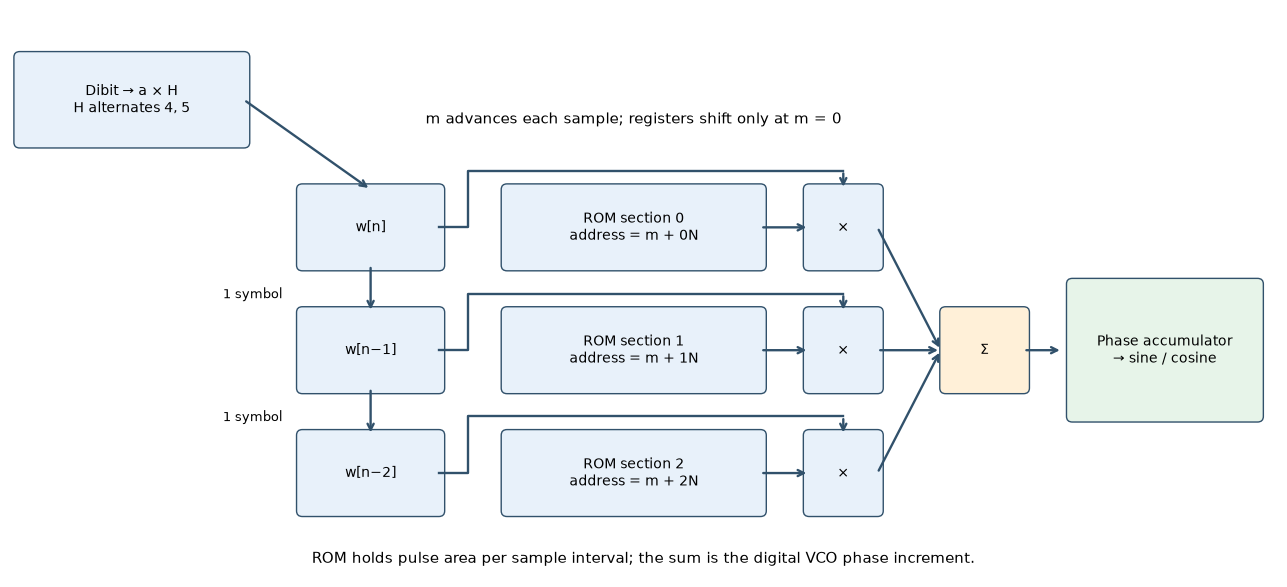

In [2]:
fig, ax = plt.subplots(figsize=(13,6))
ax.set(xlim=(0,13), ylim=(0,6)); ax.axis('off')
def box(x,y,w,h,text,color='#e8f1fa'):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.06',facecolor=color,edgecolor='#31516b'))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=10)
def arrow(a,b):
    ax.annotate('',xy=b,xytext=a,arrowprops={'arrowstyle':'->','lw':1.7,'color':'#31516b'})
box(.1,4.6,2.3,.9,'Dibit → a × H\nH alternates 4, 5')
for j,(yy,label) in enumerate([(3.3,'w[n]'),(2,'w[n−1]'),(.7,'w[n−2]')]):
    box(3,yy,1.4,.8,label)
    box(5.1,yy,2.6,.8,f'ROM section {j}\naddress = m + {j}N')
    box(8.2,yy,.7,.8,'×')
    ax.plot([4.4,4.7,4.7,8.55],[yy+.4,yy+.4,yy+1.0,yy+1.0],color='#31516b',lw=1.7)
    arrow((8.55,yy+1.0),(8.55,yy+.8)); arrow((7.7,yy+.4),(8.2,yy+.4))
    arrow((8.9,yy+.4),(9.55,2.4))
arrow((2.4,5.05),(3.7,4.1)); arrow((3.7,3.3),(3.7,2.8)); arrow((3.7,2),(3.7,1.5))
ax.text(2.8,2.95,'1 symbol',ha='right',fontsize=9)
ax.text(2.8,1.65,'1 symbol',ha='right',fontsize=9)
box(9.6,2,.8,.8,'Σ',color='#fff0d8'); arrow((10.4,2.4),(10.8,2.4))
box(10.9,1.7,1.9,1.4,'Phase accumulator\n→ sine / cosine',color='#e7f4e9')
ax.text(6.4,4.8,'m advances each sample; registers shift only at m = 0',ha='center',fontsize=11)
ax.text(6.5,.15,'ROM holds pulse area per sample interval; the sum is the digital VCO phase increment.',ha='center')
fig.tight_layout(); fig.savefig(OUT/'01_architecture.png',dpi=150); plt.show()

## 2. A pulse LUT, with its normalization visible

You can store a peak-one shape $P(u)=[1-\cos(2\pi u/3)]/2$ on $0\le u\le3$.
The standard pulse is $G(u)=Tg(Tu)=P(u)/3$. Its integral is $1/2$.
For point samples, your three-way sum is

$$\frac{\Delta f[nN+m]}{R_s}=\frac1{16}\sum_{j=0}^2w_{n-j}G(j+m/N).$$

This directly generates the black instantaneous-frequency curve. An analog VCO would follow its reconstructed continuous version.
For a digital VCO, we can improve on a rectangular numerical integrator by storing the **exact area within each sample interval**:

$$D[\ell]=Q((\ell+1)/N)-Q(\ell/N),\quad
C[\ell]=\operatorname{round}\left(\frac{2^{24}}{16}D[\ell]\right).$$

The three products now sum to phase increment counts. The interval-average frequency is
$\overline{\Delta f}=F_s\,\Delta\mathrm{word}/2^{24}$.
This is the same three-path architecture with an area LUT instead of a point-value LUT. The floating-point phase at sample boundaries
is exact for the chosen pulse; integer quantization introduces a small error.

After rounding, two central coefficients are adjusted equally to preserve symmetry and ensure
$\sum C=2^{24}/32$. Thus a completed pulse contributes exactly $w/32$ turns and does not leave a cumulative quantization bias.

In [3]:
def q(u):
    v = np.clip(np.asarray(u, dtype=float), 0, 3)
    return v / 6 - np.sin(2*np.pi*v/3) / (4*np.pi)

def g(u):
    u = np.asarray(u, dtype=float)
    return np.where((u >= 0) & (u <= 3), (1-np.cos(2*np.pi*u/3))/6, 0)

def make_rom():
    # h=H/16, H in {4,5}. Each count is 1/2**PHASE_BITS of a turn.
    ideal = MODULUS/16 * np.diff(q(np.arange(3*SPS+1)/SPS))
    table = np.rint(ideal).astype(np.int64)
    # Preserve symmetry and exact total area so completed pulses do not drift.
    correction = MODULUS//32 - int(table.sum())
    assert correction % 2 == 0
    table[len(table)//2-1:len(table)//2+1] += correction//2
    assert np.array_equal(table, table[::-1])
    assert table.sum() == MODULUS//32
    assert table.min() >= 0 and table.max() < 65536
    return table

ROM = make_rom()

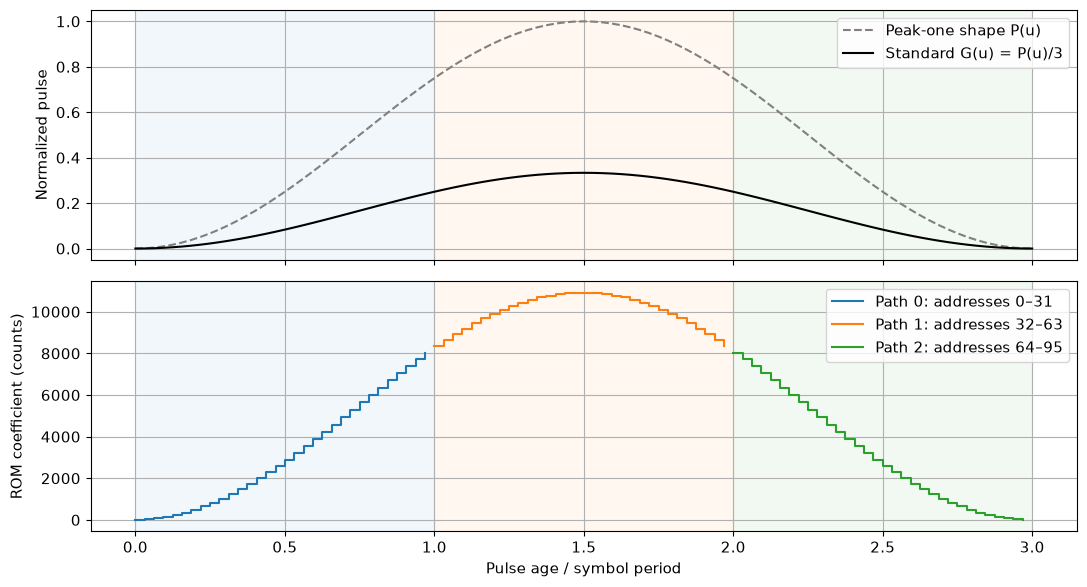

ROM: 96 coefficients, range 4...10918, sum 524288


In [4]:
u = np.arange(3*SPS+1)/SPS
average_g = np.diff(q(u))*SPS
fig, ax = plt.subplots(2,1,figsize=(11,6),sharex=True)
ax[0].plot(u,3*g(u),label='Peak-one shape P(u)',color='grey',ls='--')
ax[0].plot(u,g(u),label='Standard G(u) = P(u)/3',color='black')
ax[0].set(ylabel='Normalized pulse'); ax[0].legend()
for j, color in enumerate(['tab:blue','tab:orange','tab:green']):
    sl=slice(j*SPS,(j+1)*SPS)
    ax[1].step(u[:-1][sl],ROM[sl],where='post',color=color,label=f'Path {j}: addresses {j*SPS}–{(j+1)*SPS-1}')
    for aa in ax: aa.axvspan(j,j+1,color=color,alpha=.06)
ax[1].set(xlabel='Pulse age / symbol period',ylabel='ROM coefficient (counts)'); ax[1].legend()
fig.tight_layout(); fig.savefig(OUT/'02_lut_sections.png',dpi=150); plt.show()
print(f'ROM: {len(ROM)} coefficients, range {ROM.min()}...{ROM.max()}, sum {ROM.sum()}')

### Where are the four signed pulses?

The previous plot shows **one shared positive ROM template before symbol multiplication**.
Its three colours are three successive time sections of that template, not three dibit values.
The four signed pulses appear at the multiplier outputs. For the same index their amplitudes have ratio 3:1, not 2:1.

| Dibit | Symbol a | Weight aH when H=4 | Weight aH when H=5 |
|---|---:|---:|---:|
| 00 | −3 | −12 | −15 |
| 01 | −1 | −4 | −5 |
| 10 | +1 | +4 | +5 |
| 11 | +3 | +12 | +15 |

This is the ARTM mapping in RCC 106 Table 2-6. A normalized alphabet would be −1, −1/3, +1/3, +1;
that normalization is separate from the modulation index. The index is **h=4/16 or 5/16**, selected by symbol position,
not by dibit value. The same `00` dibit therefore has two possible negative pulse magnitudes, depending on its position.

The plots show each possible dibit's isolated full pulse; they are alternatives, not four pulses transmitted together.
Dashed lines are analytic instantaneous-frequency contributions $a h G(u)$; solid steps are the actual integer-ROM
products converted to interval-average frequency. A hardware path reads just its current third of one such pulse.
One shared ROM plus signed scaling is equivalent to pre-storing all eight dibit/index combinations, but uses less storage.

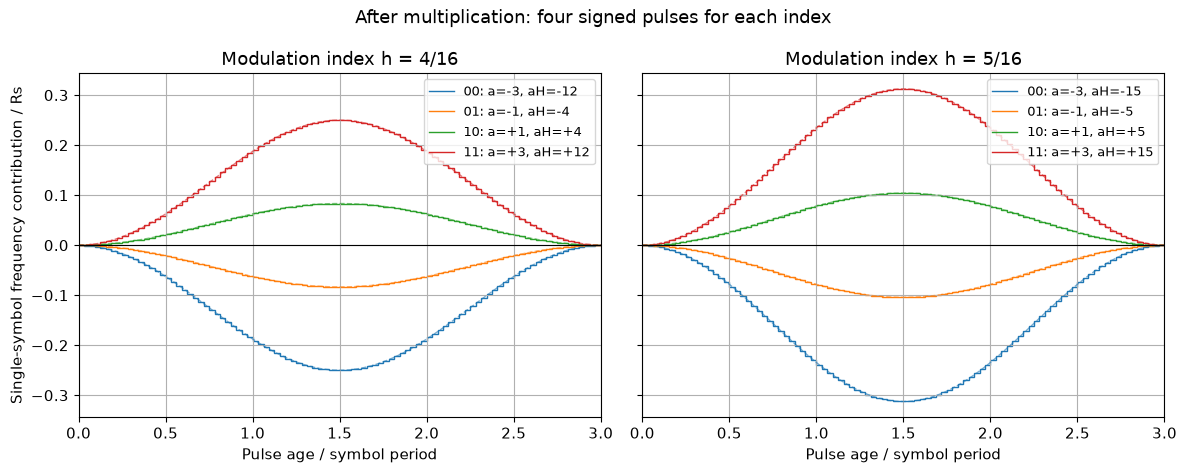

In [5]:
fig, ax = plt.subplots(1,2,figsize=(12,4.8),sharex=True,sharey=True)
dibit_colors = ['tab:blue','tab:orange','tab:green','tab:red']
for panel, H in zip(ax,[4,5]):
    for d,color in enumerate(dibit_colors):
        symbol = 2*d-3
        weighted_rom = symbol*H*ROM
        average_frequency = weighted_rom*SPS/MODULUS
        panel.stairs(average_frequency,u,color=color,label=f'{d:02b}: a={symbol:+d}, aH={symbol*H:+d}')
        panel.plot(u,symbol*(H/16)*g(u),'--',color=color,alpha=.6,lw=1)
    panel.axhline(0,color='black',lw=.8)
    panel.set(title=f'Modulation index h = {H}/16',xlabel='Pulse age / symbol period',xlim=(0,3))
    panel.legend(fontsize=9,loc='upper right')
ax[0].set_ylabel('Single-symbol frequency contribution / Rs')
fig.suptitle('After multiplication: four signed pulses for each index')
fig.tight_layout(); fig.savefig(OUT/'06_signed_symbol_pulses.png',dpi=150); plt.show()

## 3. Registers and arithmetic: one clock at a time

| Item | Representation / action |
|---|---|
| Dibit | 2 bits; `00`, `01`, `10`, `11` become −3, −1, +1, +3 |
| Weighted symbol $w=aH$ | Values ±4, ±5, ±12, ±15; fits 5 signed bits |
| Delay line | Three weights; shift once per accepted dibit |
| ROM | Three sections of 32 unsigned 16-bit coefficients |
| Products | A 5-bit signed weight times a positive 16-bit coefficient; preserve sign and full precision |
| Summer | Sum all three signed products before narrowing; 24 signed bits are ample here |
| Phase | 24-bit unsigned register; wraps modulo $2^{24}$ turns-counts |
| I/Q | Sine/cosine of phase; no phase reset at symbol boundaries |

The RTL uses bounded integer arithmetic for the products and a `numeric_std` unsigned phase accumulator.
The conservative sum bound is $3\times15\times65535=2,949,075$, below the signed 24-bit limit.

**Clock contract:** `ready` means `m=0`. A dibit transfers only when ready, valid and sample-enable are all true,
with reset low. Otherwise the next dibit waits. Inside a symbol, each enabled clock advances one sample.
Missing input at a boundary freezes waveform time; this is a simulation/interface convention.
A continuous RF transmitter must supply dibits on time, normally using buffering. A frozen DAC output is not continued CPM.

On an accepted edge the model returns the phase at the **start** of the interval, then accumulates that interval's increment.
Reset clears phase, pulse history and counter; the first symbol after reset uses $H=4$.

In [6]:
class Core:
    """One call = one fabric clock edge; one accepted step = one waveform sample.

    Input dibit is an integer 0..3 with the first bit as MSB. sample_ce can
    freeze the model. Missing dibits at m=0 also freeze waveform time.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.m = 0
        self.weights = [0, 0, 0]
        self.next_H = 4
        self.phase = 0

    @property
    def ready(self):
        return self.m == 0

    def tick(self, dibit=0, valid=False, sample_ce=True, reset=False):
        if reset:
            self.reset()
            return None
        if not sample_ce or (self.ready and not valid):
            return None
        if self.ready:
            if dibit not in range(4):
                raise ValueError('dibit must be 0..3')
            symbol = 2*int(dibit)-3
            self.weights = [symbol*self.next_H, *self.weights[:2]]
            self.next_H = 9-self.next_H
        branches = [self.weights[j]*int(ROM[j*SPS+self.m]) for j in range(3)]
        increment = sum(branches)
        result = {'m': self.m, 'weights': self.weights.copy(), 'branches': branches,
                  'increment': increment, 'phase': self.phase}
        self.phase = (self.phase+increment) % MODULUS
        self.m = (self.m+1) % SPS
        return result

def run(dibits):
    core = Core()
    trace = []
    for dibit in dibits:
        for _ in range(SPS):
            trace.append(core.tick(int(dibit), valid=True))
    return trace

## 4. Follow repeated dibits through the three paths

The first two inputs below are both `00`: their weights are −12 and −15 because the indices alternate.
Each weight moves through the first, middle, then last pulse section. Old pulses keep their original weight.
The initial two-symbol transient is expected: reset starts with no earlier pulse history.

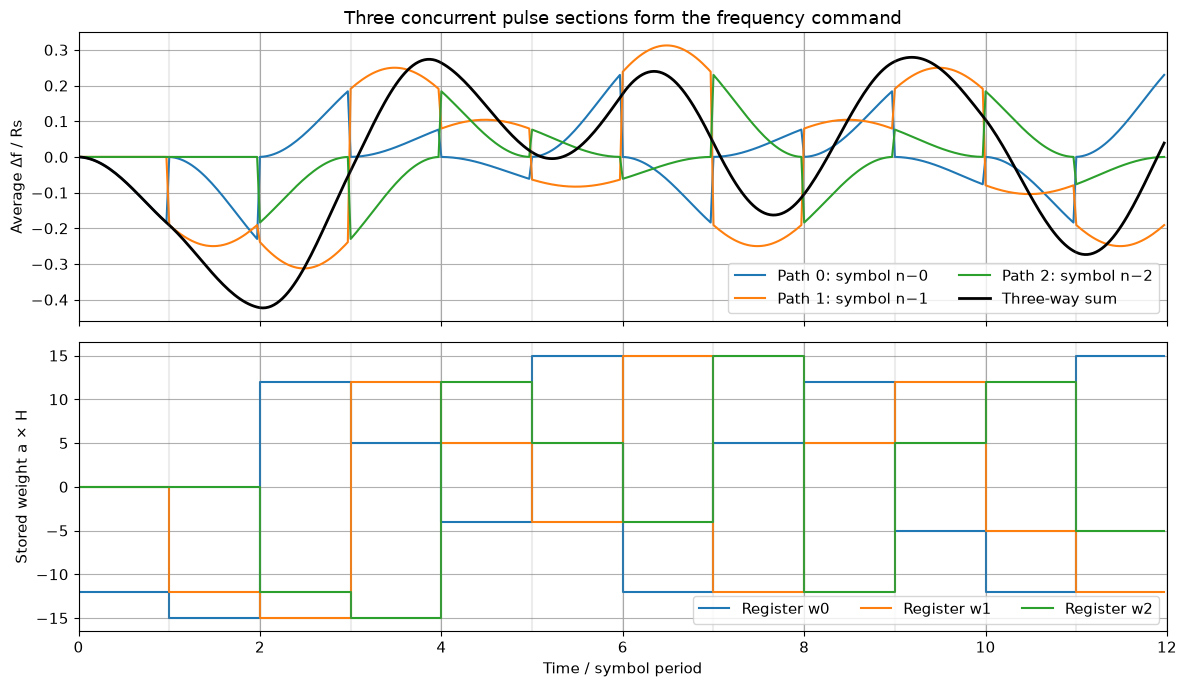

n  dibit  H   [newest, previous, oldest]
0  00     4   [-12, 0, 0]
1  00     5   [-15, -12, 0]
2  11     4   [12, -15, -12]
3  10     5   [5, 12, -15]
4  01     4   [-4, 5, 12]
5  11     5   [15, -4, 5]
6  00     4   [-12, 15, -4]
7  10     5   [5, -12, 15]


In [7]:
dibits = np.array([0,0,3,2,1,3,0,2,3,1,0,3])
trace = run(dibits)
branches = np.array([r['branches'] for r in trace])
increments = np.array([r['increment'] for r in trace])
phase_words = np.array([r['phase'] for r in trace])
xx = np.arange(len(trace))/SPS
fig, ax = plt.subplots(2,1,figsize=(12,7),sharex=True)
colors=['tab:blue','tab:orange','tab:green']
for j in range(3):
    ax[0].plot(xx,branches[:,j]*SPS/MODULUS,label=f'Path {j}: symbol n−{j}',color=colors[j])
ax[0].plot(xx,increments*SPS/MODULUS,color='black',lw=2,label='Three-way sum')
ax[0].set(ylabel='Average Δf / Rs',title='Three concurrent pulse sections form the frequency command'); ax[0].legend(ncol=2)
weights = np.array([r['weights'] for r in trace])
for j in range(3): ax[1].step(xx,weights[:,j],where='post',color=colors[j],label=f'Register w{j}')
ax[1].set(xlabel='Time / symbol period',ylabel='Stored weight a × H'); ax[1].legend(ncol=3)
for aa in ax:
    for k in range(len(dibits)+1): aa.axvline(k,color='grey',alpha=.15)
    aa.set_xlim(0,len(dibits))
fig.tight_layout(); fig.savefig(OUT/'03_three_paths.png',dpi=150); plt.show()
print('n  dibit  H   [newest, previous, oldest]')
for n,d in enumerate(dibits[:8]):
    print(f'{n:<2} {d:02b}     {4+n%2}   {trace[n*SPS]["weights"]}')

## 5. Virtual VCO: phase accumulation and an output sine/cosine ROM

$$p[k+1]=(p[k]+\Delta\mathrm{word}[k])\bmod 2^{24},\quad
I[k]=\cos(2\pi p[k]/2^{24}),\quad Q[k]=\sin(2\pi p[k]/2^{24}).$$

The counter wrapping is just an angle crossing a whole turn, not a phase discontinuity in the RF waveform.
Below, the 12 most significant phase bits address a 4096-entry sine/cosine ROM with 16-bit signed output.
Discarding phase-address bits and quantizing amplitude introduce additional error and possible spurs.
The RTL file stops at the phase word; this Python cell demonstrates the downstream ROM block explicitly.
An FPGA may instead use a quarter-wave table or CORDIC.

For a digital IF carrier, add a carrier increment $\operatorname{round}(2^{24}f_c/F_s)$ to the accumulator
on every sample advance. Baseband I/Q needs no carrier increment; the example below shows both representations.

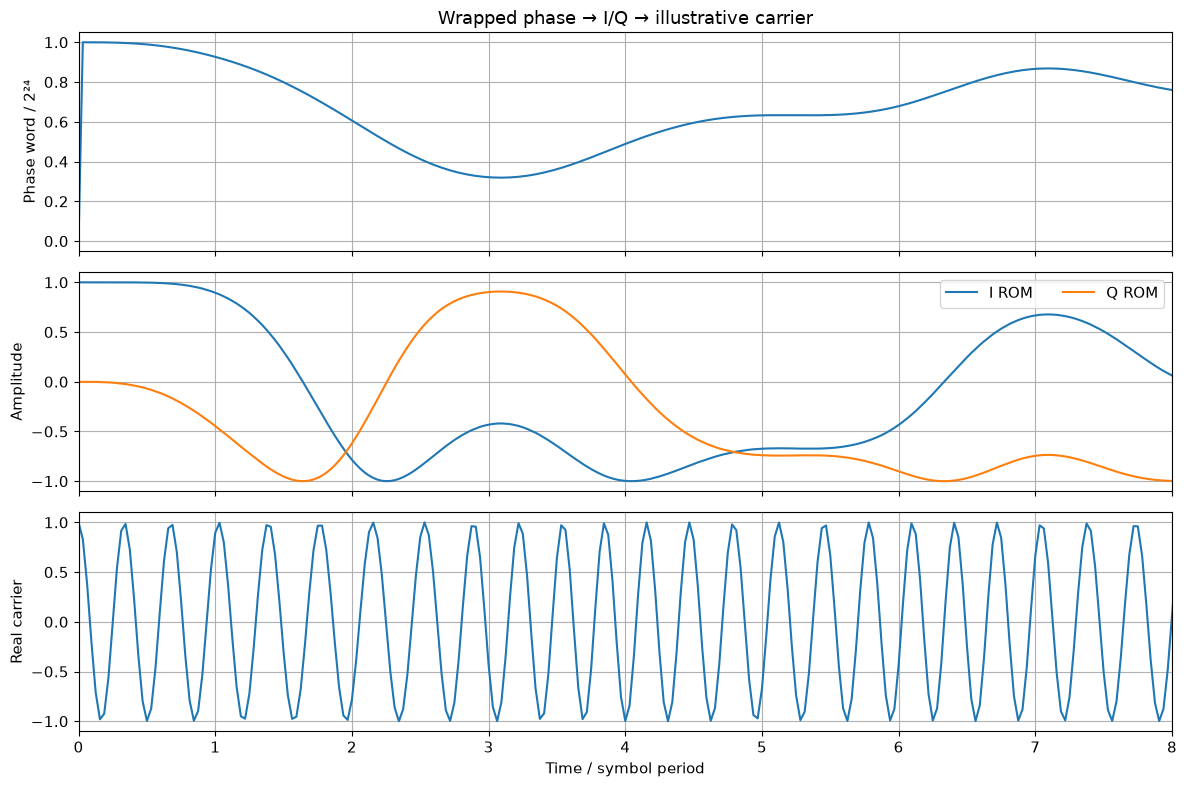

Max complex error from the illustrative output I/Q ROM: 0.00154098


In [8]:
LUT_BITS = 12
angles = 2*np.pi*np.arange(1<<LUT_BITS)/(1<<LUT_BITS)
i_rom = np.rint(32767*np.cos(angles)).astype(np.int16)
q_rom = np.rint(32767*np.sin(angles)).astype(np.int16)
address = phase_words >> (PHASE_BITS-LUT_BITS)
iq_lut = (i_rom[address].astype(float)+1j*q_rom[address].astype(float))/32767
iq_phase = np.exp(2j*np.pi*phase_words/MODULUS)
time = np.arange(len(trace))/Fs
if_wave = np.real(iq_phase*np.exp(2j*np.pi*(3*Rs)*time))
fig, ax = plt.subplots(3,1,figsize=(12,8),sharex=True)
ax[0].plot(xx,phase_words/MODULUS); ax[0].set(ylabel='Phase word / 2²⁴',title='Wrapped phase → I/Q → illustrative carrier')
ax[1].plot(xx,iq_lut.real,label='I ROM'); ax[1].plot(xx,iq_lut.imag,label='Q ROM'); ax[1].legend(ncol=2); ax[1].set(ylabel='Amplitude')
ax[2].plot(xx,if_wave); ax[2].set(xlabel='Time / symbol period',ylabel='Real carrier')
for aa in ax: aa.set_xlim(0,8)
fig.tight_layout(); fig.savefig(OUT/'04_virtual_vco.png',dpi=150); plt.show()
print(f'Max complex error from the illustrative output I/Q ROM: {np.max(np.abs(iq_lut-iq_phase)):.6g}')

## 6. Check against the floating-point waveform

The reference uses the first notebook's analytic phase pulse and a convolution, not the clocked register loop.
Compare complex waveforms or wrapped phase differences; subtracting two wrapped phase words directly gives false spikes at wrap points.
The tests also check repeated data, pulse area, no state advance during stalls, and reset.

In [9]:
def reference(dibits):
    """Floating-point convolution, independent of the clocked shift-register loop."""
    symbols = 2*np.asarray(dibits, dtype=int)-3
    h = np.resize([4/16, 5/16], len(symbols))
    impulses = np.zeros(len(symbols)*SPS)
    impulses[::SPS] = symbols*h
    dq = np.diff(q(np.arange(3*SPS+1)/SPS))
    phase_turns = np.r_[0., np.cumsum(np.convolve(impulses, dq))]
    frequency = np.convolve(impulses, g(np.arange(3*SPS+1)/SPS))
    n = len(impulses)
    return phase_turns[:n], frequency[:n]

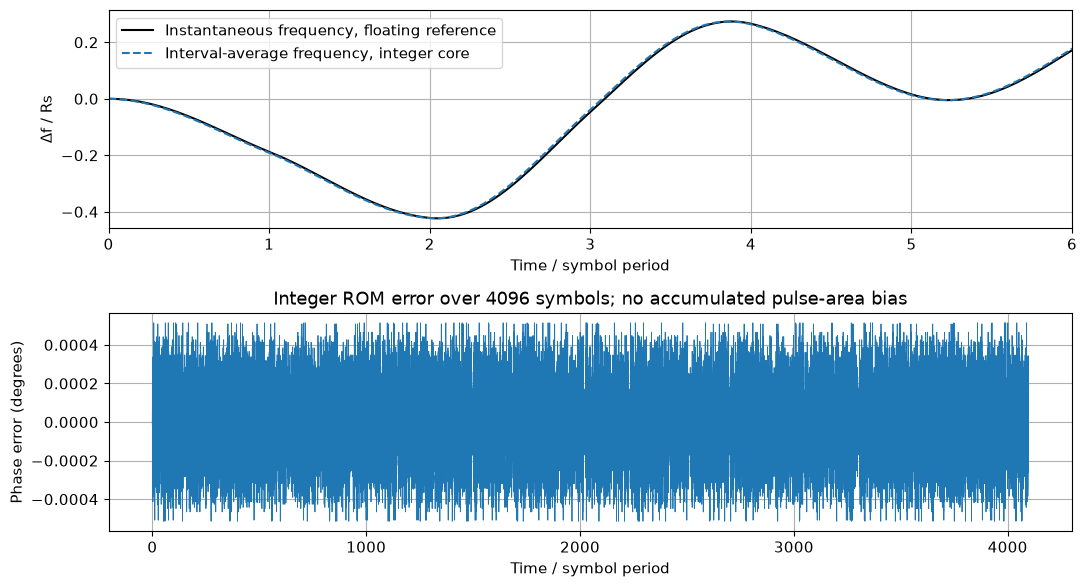

Max phase error: 0.000514 degrees
Max complex-baseband error: 8.97662e-06
PASS: floating reference, repeated dibits, ROM area, stalls, and reset checks


In [10]:
rng = np.random.default_rng(106)
test_dibits = rng.integers(0,4,4096)
long_trace = run(test_dibits)
fixed_phase = np.array([r['phase'] for r in long_trace])/MODULUS
float_phase, float_freq = reference(test_dibits)
phase_error = np.angle(np.exp(2j*np.pi*(fixed_phase-float_phase)))
complex_error = np.abs(np.exp(2j*np.pi*fixed_phase)-np.exp(2j*np.pi*float_phase))
assert np.max(np.abs(phase_error)) < 1e-3
assert ROM.sum() == MODULUS//32
assert trace[0]['weights'] == [-12,0,0]
assert trace[SPS]['weights'] == [-15,-12,0]
# An accepted-sample stream is unchanged by CE and input-valid gaps.
c = Core(); accepted=[]; n=0
for cycle in range(5000):
    if n >= len(trace): break
    r = c.tick(int(dibits[n//SPS]),valid=(cycle%7!=0),sample_ce=(cycle%5!=0))
    if r is not None:
        accepted.append(r); n+=1
assert accepted == trace
assert c.tick(reset=True) is None and c.phase == 0 and c.weights == [0,0,0] and c.next_H == 4
fig, ax = plt.subplots(2,1,figsize=(11,6))
short_reference, short_freq = reference(dibits)
ax[0].plot(xx,short_freq,color='black',label='Instantaneous frequency, floating reference')
ax[0].plot(xx,increments*SPS/MODULUS,'--',label='Interval-average frequency, integer core')
ax[0].set(xlim=(0,6),xlabel='Time / symbol period',ylabel='Δf / Rs'); ax[0].legend()
ax[1].plot(np.arange(len(phase_error))/SPS,np.rad2deg(phase_error),lw=.6)
ax[1].set(xlabel='Time / symbol period',ylabel='Phase error (degrees)',title='Integer ROM error over 4096 symbols; no accumulated pulse-area bias')
fig.tight_layout(); fig.savefig(OUT/'05_verification.png',dpi=150); plt.show()
print(f'Max phase error: {np.rad2deg(np.max(np.abs(phase_error))):.6f} degrees')
print(f'Max complex-baseband error: {complex_error.max():.6g}')
print('PASS: floating reference, repeated dibits, ROM area, stalls, and reset checks')

## 7. Translate the model into VHDL

The complete core is shown below and saved in `hardware/cpm_core.vhd`. Its companion ROM package is generated
from exactly the same integer coefficients. `hardware/tb_cpm_core.vhd` compares 6000 fabric-clock vectors from Python.

Notice the **variables** `v0`, `v1`, `v2` in the clocked process. On a symbol boundary, they let the first output sample
use the newly accepted symbol immediately. Reading `w0` after assigning `w0 <= ...` in that same process would still read
the old signal value and produce an incorrect first sample.

Three ROM reads and products form one combinational path before the output registers. This is a functional architecture,
not a claim of timing closure. A synchronous block RAM or pipelined DSP implementation needs delayed counters, weights,
valid flags and phase updates so all three products continue to refer to the same sample.

```vhdl
-- VHDL-2008 teaching core: three concurrent pulse sections and phase accumulator.
-- Combinational ROM reads + multipliers + summer in one clock path.
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;
use work.cpm_rom_pkg.all;

entity cpm_core is
  port (
    clk, reset, sample_ce : in std_logic;
    dibit : in std_logic_vector(1 downto 0);
    dibit_valid : in std_logic;
    dibit_ready : out std_logic;
    out_valid : out std_logic;
    delta_word : out signed(PHASE_BITS-1 downto 0);
    phase_word : out unsigned(PHASE_BITS-1 downto 0)
  );
end entity;

architecture rtl of cpm_core is
  signal m : integer range 0 to SPS-1 := 0;
  signal w0, w1, w2 : integer range -15 to 15 := 0;
  signal next_h : integer range 4 to 5 := 4;
  signal accumulator : unsigned(PHASE_BITS-1 downto 0) := (others => '0');
begin
  dibit_ready <= '1' when m = 0 else '0';
  process(clk)
    variable a : integer range -3 to 3;
    variable v0, v1, v2 : integer range -15 to 15;
    variable b0, b1, b2 : integer range -983025 to 983025;
    variable total : integer range -2949075 to 2949075;
  begin
    if rising_edge(clk) then
      out_valid <= '0';
      if reset = '1' then
        m <= 0; w0 <= 0; w1 <= 0; w2 <= 0; next_h <= 4;
        accumulator <= (others => '0');
        phase_word <= (others => '0'); delta_word <= (others => '0');
      elsif sample_ce = '1' and (m /= 0 or dibit_valid = '1') then
        v0 := w0; v1 := w1; v2 := w2;
        if m = 0 then
          case dibit is
            when "00" => a := -3;
            when "01" => a := -1;
            when "10" => a := 1;
            when "11" => a := 3;
            when others => a := 0; -- simulation unknowns, not a valid input
          end case;
          v2 := w1; v1 := w0; v0 := a*next_h;
          w2 <= v2; w1 <= v1; w0 <= v0;
          next_h <= 9-next_h;
        end if;
        -- All three products describe the same output sample.
        b0 := v0*AREA_ROM(m);
        b1 := v1*AREA_ROM(SPS+m);
        b2 := v2*AREA_ROM(2*SPS+m);
        total := b0+b1+b2;
        delta_word <= to_signed(total, PHASE_BITS);
        -- Output phase at START of this interval, then integrate its area.
        phase_word <= accumulator;
        accumulator <= accumulator + unsigned(to_signed(total, PHASE_BITS));
        out_valid <= '1';
        if m = SPS-1 then m <= 0; else m <= m+1; end if;
      end if;
    end if;
  end process;
end architecture;

```

In [11]:
import cpm_hardware
assert np.array_equal(ROM,cpm_hardware.ROM)
rtl_dir = cpm_hardware.export()
print('Generated:', rtl_dir/'cpm_rom_pkg.vhd', 'and', rtl_dir/'vectors.txt')

Generated: hardware\cpm_rom_pkg.vhd and hardware\vectors.txt


### Compile and simulate

From the `hardware` directory, with GHDL available:

```powershell
ghdl -a --std=08 cpm_rom_pkg.vhd cpm_core.vhd tb_cpm_core.vhd
ghdl -e --std=08 tb_cpm_core
ghdl -r --std=08 tb_cpm_core --assert-level=error
```

The next cell runs these commands automatically if GHDL is installed or available in the project's portable tools folder.
It reports a skip explicitly when unavailable. Passing establishes agreement with the Python clock model, not FPGA timing or RF compliance.

In [12]:
import shutil, subprocess
ghdl = shutil.which('ghdl')
if not ghdl:
    candidates = list(Path('.tools/ghdl').rglob('ghdl.exe')) if Path('.tools/ghdl').exists() else []
    if candidates: ghdl = str(candidates[0].resolve())
if ghdl:
    for args in [
        ['-a','--std=08','cpm_rom_pkg.vhd','cpm_core.vhd','tb_cpm_core.vhd'],
        ['-e','--std=08','tb_cpm_core'],
        ['-r','--std=08','tb_cpm_core','--assert-level=error'],
    ]:
        result = subprocess.run([ghdl,*args],cwd=rtl_dir,text=True,capture_output=True,timeout=120)
        print(result.stdout+result.stderr)
        result.check_returncode()
else:
    print('SKIPPED: GHDL unavailable. Python tests ran; VHDL compilation/simulation not verified here.')

tb_cpm_core.vhd:46:5:@60006ns:(report note): PASS: 6000 clock vectors
simulation stopped @60006ns



## Source guide and implementation boundaries

- [RCC 106-20, Chapter 2, §2.3.3.3 and Table 2-6](https://www.trmc.osd.mil/wiki/download/attachments/240256843/chapter2.pdf?api=v2&modificationDate=1692197849361&version=1): mapping, alternating indices and pulse definition.
- [Geoghegan, ARTM Tier II waveform](https://www.quasonix.com/files/artm-tier-ii-waveform-itc-paper.pdf): continuous-phase waveform and frequency/phase generation descriptions.
- [GHDL simulation workflow](https://ghdl.github.io/ghdl/quick_start/simulation/index.html): analyze, elaborate and run commands.
- [IEEE numeric_std implementation distributed with GHDL](https://github.com/ghdl/ghdl/blob/master/libraries/ieee/numeric_std-body.vhdl): signed/unsigned arithmetic support.

The three-path decomposition, fixed-point choices, pulse-area correction, interface and example RTL are our implementation design,
not a prescribed standard hardware circuit. The first notebook's unresolved few-dB paper-figure comparison remains unresolved;
these tests do not remove that external-validation limitation.

Serial-bit packing, clock-domain crossing, input FIFO, a synthesizable sine/cosine output block, DAC interfaces, and analog VCO circuitry
are outside this core. Startup has zero pulse history. `00` is a real negative-frequency symbol, never a zero-valued tail filler.
There is no burst-flush input: in continuous operation keep supplying valid data. Reset intentionally breaks phase continuity across bursts.